In [1]:
import numpy as np # Linear Algebra
import pandas as pd # Data processing
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('wine_data.csv',header = None,usecols=[0,1,2])
df.columns = ['Class label','Alcohol','Malic acid']

In [3]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

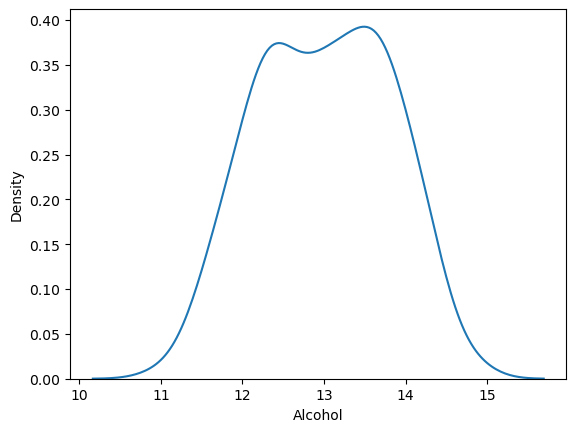

In [4]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

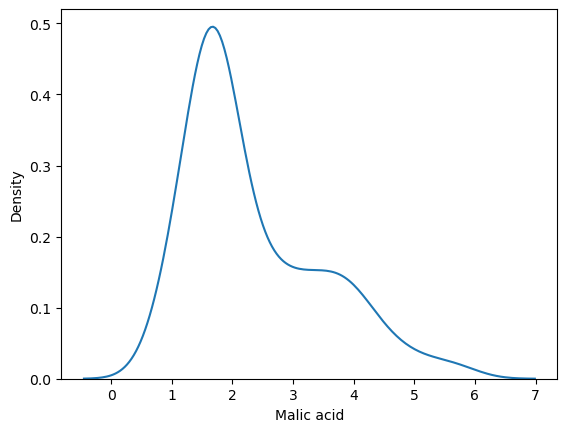

In [5]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

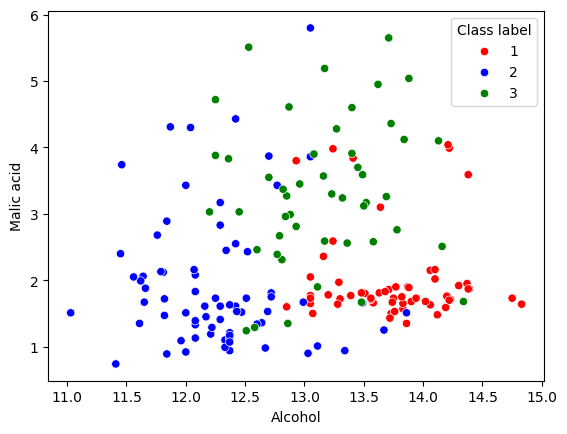

In [6]:
color_dict = {1:'red',3:'green',2:'blue'}
sns.scatterplot(data = df, x = 'Alcohol' , y = 'Malic acid',hue = df['Class label'],palette= color_dict)

# for Knowing a data

# Train Test Split

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test ,y_train , y_test = train_test_split(df.drop('Class label', axis =1),
                                                     df['Class label'],
                                                     test_size = 0.3,
                                                     random_state = 0)

X_train.shape , X_test.shape

'''
Key Components
df.drop('Class label', axis=1) creates feature matrix X (all columns except target).

df['Class label'] is target vector y (wine classes to predict).

test_size=0.3 allocates 30% to test set, 70% to train set.

random_state=0 ensures reproducible splits by fixing the random seed.
'''

"\nKey Components\ndf.drop('Class label', axis=1) creates feature matrix X (all columns except target).\n\ndf['Class label'] is target vector y (wine classes to predict).\n\ntest_size=0.3 allocates 30% to test set, 70% to train set.\n\nrandom_state=0 ensures reproducible splits by fixing the random seed.\n"

# MIN MAX Scaling

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters

scaler.fit(X_train)        # finded Min & Max Values

# transform Train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# sklearn converted data into Numpy array so we converting back to pandas DF

X_train_scaled = pd.DataFrame(X_train_scaled,columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled , columns = X_test.columns)

In [10]:
np.round(X_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [11]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


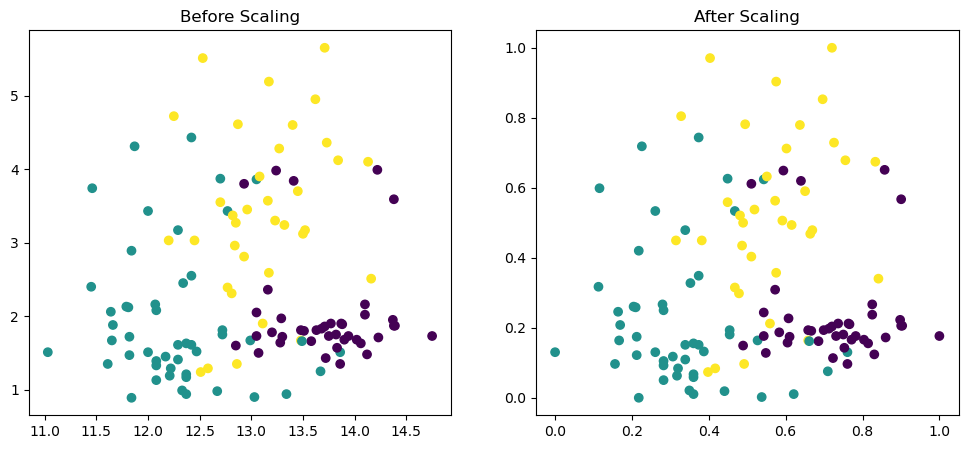

In [12]:

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
ax1.scatter(X_train['Alcohol'],X_train['Malic acid'], c = y_train)
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Alcohol'],X_train_scaled['Malic acid'], c = y_train )
ax2.set_title('After Scaling')
plt.show()

                               

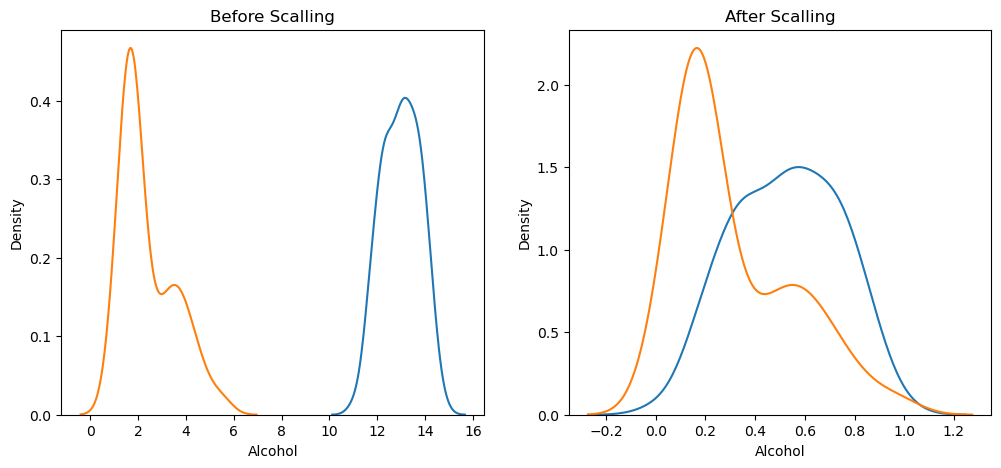

In [13]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))


## Drawing  PDF
# Before Scaling

ax1.set_title('Before Scalling')
sns.kdeplot(X_train['Alcohol'], ax = ax1)
sns.kdeplot(X_train['Malic acid'], ax = ax1)


ax2.set_title('After Scalling')
sns.kdeplot(X_train_scaled['Alcohol'], ax = ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax = ax2)

plt.show()

# Now both are in 0 - 1 Range

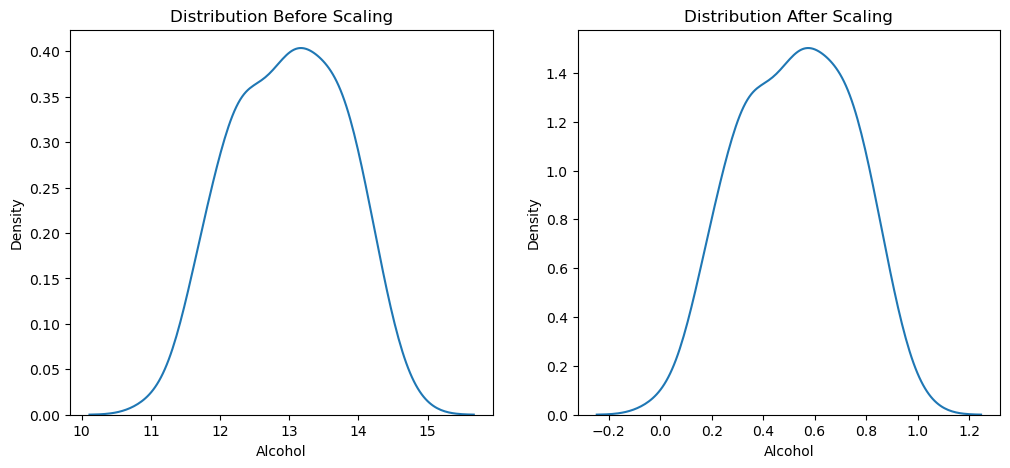

In [14]:

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Distribution After Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()



## Graphs can be change in some cases

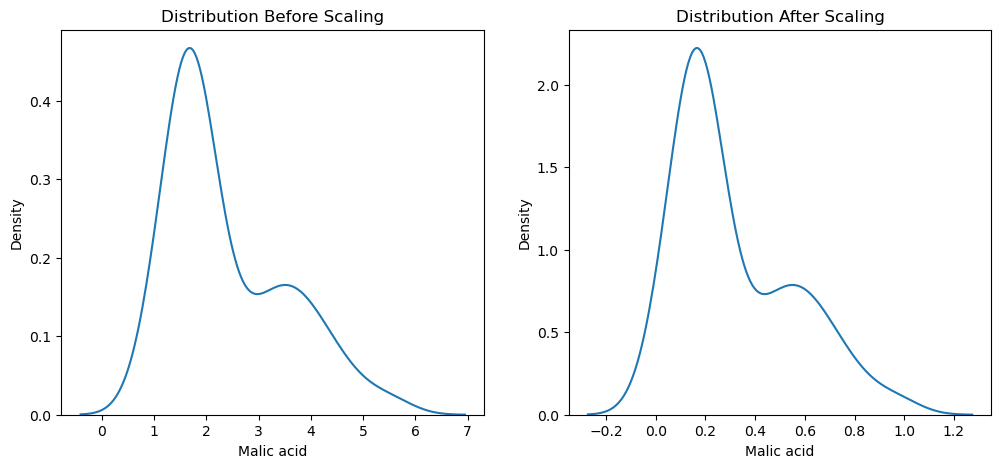

In [15]:

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Distribution After Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()





## Graphs can be change in some cases

## NOTE

When we do scaling , Outliers Impact also get squized. 


# 2. Mean Normalization

- also known as Mean Centoring
- same as Standard Scaling
- No Specific class in sklearn

## When to Use 
- When required Centorized Data
  

# 3. Max Abs Scaling

## When to use - when we have Too Much zeroes  /  having sparse data

### Class - MaxAbsScaler


In [16]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()

# fit the scaler to the train set, it will learn the parameters

scaler.fit(X_train)        

# transform Train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# sklearn converted data into Numpy array so we converting back to pandas DF

X_train_scaled = pd.DataFrame(X_train_scaled,columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled , columns = X_test.columns)

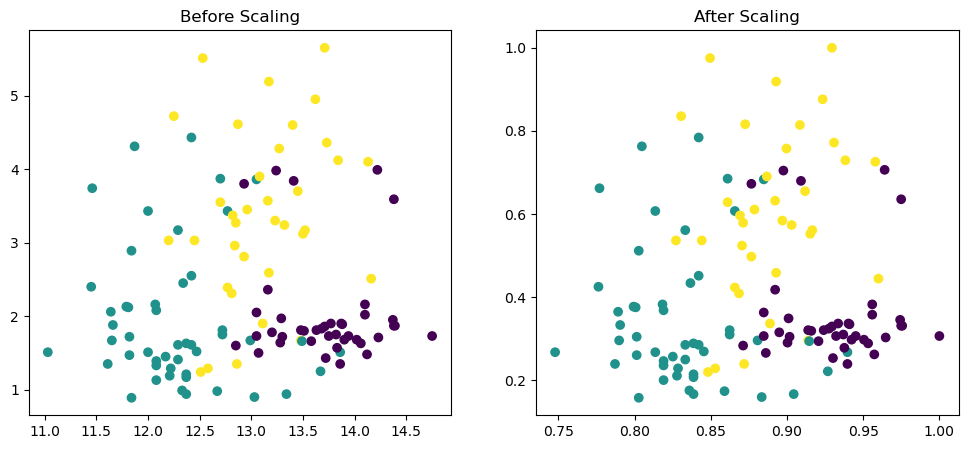

In [18]:

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
ax1.scatter(X_train['Alcohol'],X_train['Malic acid'], c = y_train)
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Alcohol'],X_train_scaled['Malic acid'], c = y_train )
ax2.set_title('After Scaling')
plt.show()

                               

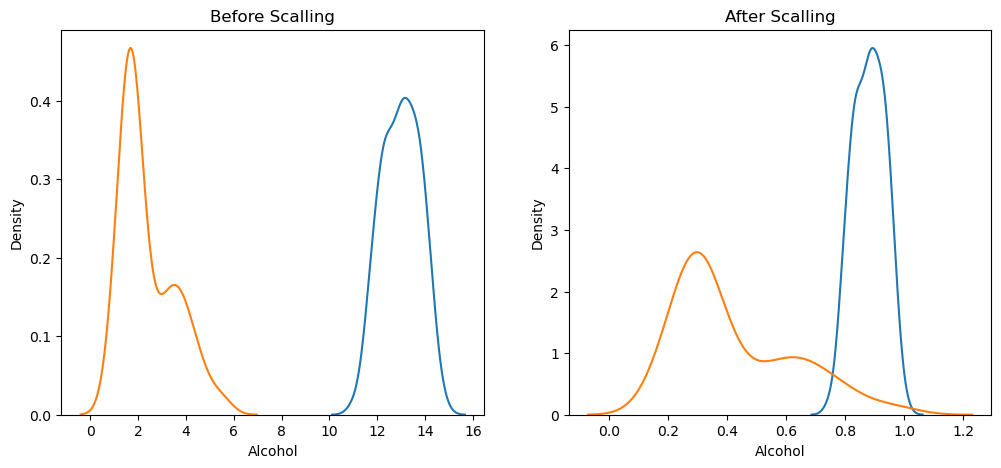

In [19]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))


## Drawing  PDF
# Before Scaling

ax1.set_title('Before Scalling')
sns.kdeplot(X_train['Alcohol'], ax = ax1)
sns.kdeplot(X_train['Malic acid'], ax = ax1)


ax2.set_title('After Scalling')
sns.kdeplot(X_train_scaled['Alcohol'], ax = ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax = ax2)

plt.show()

# Now both are in 0 - 1 Range
# Here Results more likely to Maximum area

# 4. Robust Scaling

## When to Use - when have too much Outliers --> Robust to Outliers

### class - RobustScaling

In [20]:
 from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# fit the scaler to the train set, it will learn the parameters

scaler.fit(X_train)        

# transform Train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# sklearn converted data into Numpy array so we converting back to pandas DF

X_train_scaled = pd.DataFrame(X_train_scaled,columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled , columns = X_test.columns)

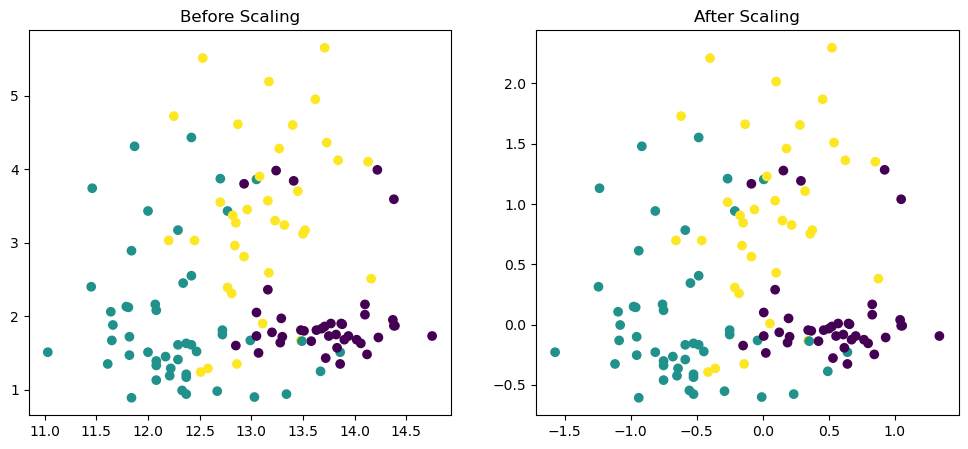

In [22]:

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
ax1.scatter(X_train['Alcohol'],X_train['Malic acid'], c = y_train)
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Alcohol'],X_train_scaled['Malic acid'], c = y_train )
ax2.set_title('After Scaling')
plt.show()

                               

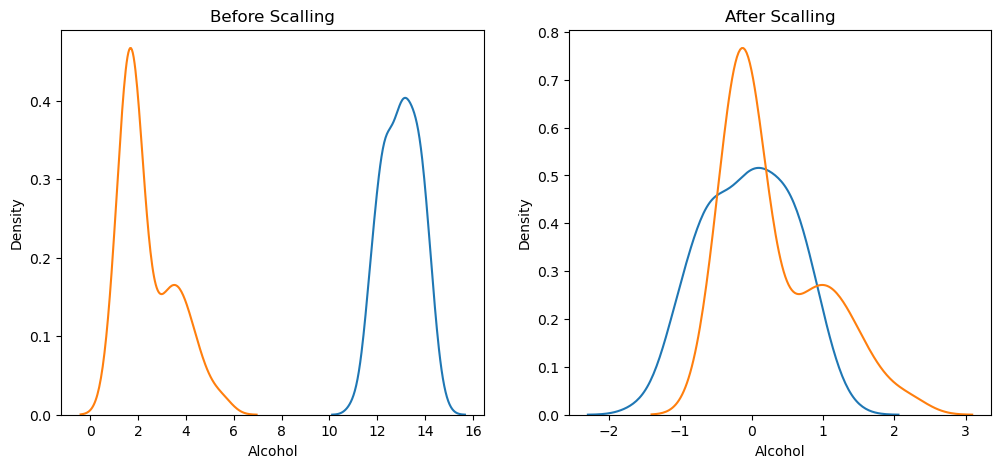

In [23]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))


## Drawing  PDF
# Before Scaling

ax1.set_title('Before Scalling')
sns.kdeplot(X_train['Alcohol'], ax = ax1)
sns.kdeplot(X_train['Malic acid'], ax = ax1)


ax2.set_title('After Scalling')
sns.kdeplot(X_train_scaled['Alcohol'], ax = ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax = ax2)

plt.show()



# Normalization Vs. Standardization

1] Is feature scaling required?

2] Mostly work done by Standardscaling

3] Min Max --> when we know min and maximum of given quantity
    |
  CNN --> [0, 225]

